In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [19]:
PROJECT_DIR = Path.cwd().parent

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

In [20]:
expression_filtered = pd.read_csv(
    PROCESSED_DIR / "expression_filtered.csv",
    index_col=0
)

clinical_matched = pd.read_csv(
    PROCESSED_DIR / "clinical_matched.csv",
    index_col=0
)

In [21]:
print(expression_filtered.shape)
print(clinical_matched.shape)

(17030, 744)
(744, 193)


In [22]:
tnbc_samples = clinical_matched[
    (clinical_matched["ER_Status_nature2012"] == "Negative") &
    (clinical_matched["PR_Status_nature2012"] == "Negative") &
    (clinical_matched["HER2_Final_Status_nature2012"] == "Negative")
].index

non_tnbc_samples = clinical_matched.index.difference(tnbc_samples)

print("TNBC:", len(tnbc_samples))
print("Non-TNBC:", len(non_tnbc_samples))

TNBC: 123
Non-TNBC: 621


In [23]:
expression_tnbc = expression_filtered[tnbc_samples]

expression_non_tnbc = expression_filtered[non_tnbc_samples]

In [25]:
results = []

for gene in expression_filtered.index:

    t_stat, pvalue = ttest_ind(
        expression_tnbc.loc[gene],
        expression_non_tnbc.loc[gene],
        equal_var=False
    )

    log2fc = (
        expression_tnbc.loc[gene].mean()
        - expression_non_tnbc.loc[gene].mean()
    )

    results.append([gene, log2fc, pvalue])

deg_results = pd.DataFrame(
    results,
    columns=[
        "Gene",
        "log2FoldChange",
        "pvalue"
    ]
)

In [26]:
deg_results["adj_pvalue"] = multipletests(
    deg_results["pvalue"],
    method="fdr_bh"
)[1]

In [27]:
deg_results = deg_results.sort_values(
    "adj_pvalue"
)

In [28]:
significant = deg_results[
    (deg_results["adj_pvalue"] < 0.05) &
    (deg_results["log2FoldChange"].abs() > 1)
]

print("Significant genes:", len(significant))

Significant genes: 2522


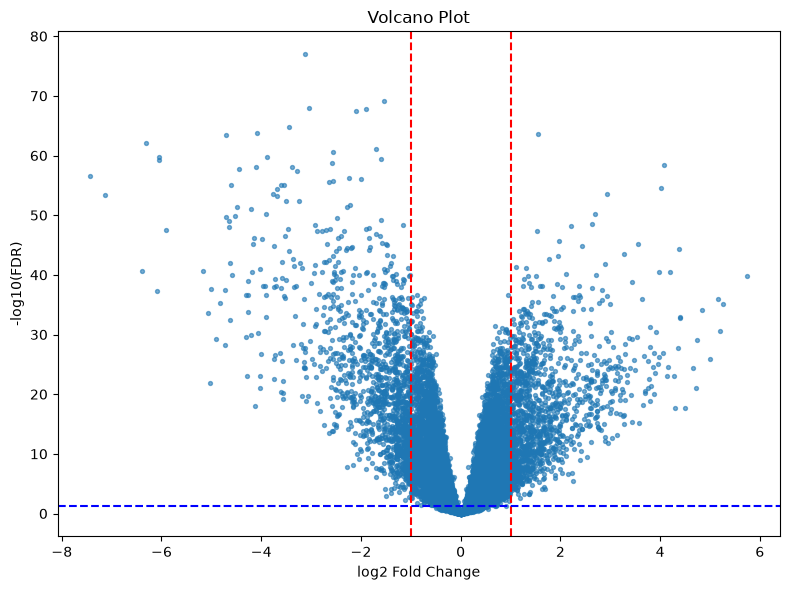

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    deg_results["log2FoldChange"],
    -np.log10(deg_results["adj_pvalue"]),
    s=8,
    alpha=0.6
)

plt.axvline(1, color="red", linestyle="--")
plt.axvline(-1, color="red", linestyle="--")

plt.axhline(
    -np.log10(0.05),
    color="blue",
    linestyle="--"
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot")

plt.tight_layout()
plt.show()

In [30]:
deg_results.head(20)

,Gene,log2FoldChange,pvalue,adj_pvalue
1268,TPSG1,-3.126257,6.352059e-82,1.081756e-77
2065,RABEP1,-1.546172,9.434222e-74,8.033240e-70
3526,TUBA3E,-3.031507,1.609079e-72,9.134207e-69
2693,KRT37,-1.890717,3.747235e-72,1.595385e-68
3948,C6orf211,-2.097727,1.162415e-71,3.959184e-68
2176,SLC16A6,-3.448325,5.362767e-69,1.522132e-65
3411,NAT1,-4.083665,8.067317e-68,1.962663e-64
11092,UBE2E3,1.546222,1.261585e-67,2.685598e-64
1228,FSIP1,-4.704536,1.991360e-67,3.768095e-64
13902,CYP2B7P1,-6.309559,4.170076e-66,7.101640e-63


In [31]:
deg_results.to_csv(
    PROCESSED_DIR / "DEG_results.csv",
    index=False
)

significant.to_csv(
    PROCESSED_DIR / "Significant_DEGs.csv",
    index=False
)